In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv("/content/retail_store_inventory.csv")

In [3]:
df.head(10)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer
5,2022-01-01,S001,P0006,Groceries,South,138,128,102,139.82,76.83,10,Sunny,1,79.35,Winter
6,2022-01-01,S001,P0007,Furniture,East,359,97,167,108.92,34.16,10,Rainy,1,36.55,Winter
7,2022-01-01,S001,P0008,Clothing,North,380,312,54,329.73,97.99,5,Cloudy,0,100.09,Spring
8,2022-01-01,S001,P0009,Electronics,West,183,175,135,174.15,20.74,10,Cloudy,0,17.66,Autumn
9,2022-01-01,S001,P0010,Toys,South,108,28,196,24.47,59.99,0,Rainy,1,61.21,Winter


In [4]:
print("rows and columns:",df.shape)

rows and columns: (73100, 15)


In [5]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [7]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [8]:
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Demand Forecast,0
Price,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Category"].unique()

array(['Groceries', 'Toys', 'Electronics', 'Furniture', 'Clothing'],
      dtype=object)

In [11]:
df["Weather Condition"].unique()

array(['Rainy', 'Sunny', 'Cloudy', 'Snowy'], dtype=object)

In [12]:
df["Seasonality"].unique()

array(['Autumn', 'Summer', 'Winter', 'Spring'], dtype=object)

In [13]:
df["Holiday/Promotion"].unique()

array([0, 1])

In [14]:
df["Price"].describe()

,Price
count,73100.000000
mean,55.135108
std,26.021945
min,10.000000
25%,32.650000
50%,55.050000
75%,77.860000
max,100.000000


In [15]:
# ===============================
# STEP 2 : DATA CLEANING
# ===============================

In [16]:
df["Date"] = pd.to_datetime(df["Date"])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Category            73100 non-null  object        
 4   Region              73100 non-null  object        
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  object        
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64   

In [18]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [19]:
(df.select_dtypes(include=["int64", "float64"]) < 0).sum()

,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Demand Forecast,673
Price,0
Discount,0
Holiday/Promotion,0
Competitor Pricing,0


In [20]:
df[df["Demand Forecast"] < 0]

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
63,2022-01-01,S004,P0004,Groceries,West,437,0,160,-2.40,87.23,10,Sunny,0,90.36,Spring
141,2022-01-02,S003,P0002,Groceries,East,175,2,140,-3.40,87.50,0,Rainy,0,91.20,Autumn
278,2022-01-03,S004,P0019,Toys,North,140,1,47,-3.91,80.41,0,Snowy,0,76.90,Winter
511,2022-01-06,S001,P0012,Groceries,North,59,1,88,-8.37,63.21,0,Rainy,0,60.48,Spring
730,2022-01-08,S002,P0011,Electronics,South,64,7,79,-2.99,92.43,0,Snowy,0,88.55,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72716,2023-12-29,S001,P0017,Clothing,North,487,7,132,-0.73,55.34,0,Sunny,1,58.03,Summer
72722,2023-12-29,S002,P0003,Toys,West,199,4,180,-5.50,82.08,10,Cloudy,1,77.99,Spring
72859,2023-12-30,S003,P0020,Toys,North,203,1,119,-7.68,94.33,5,Sunny,1,96.79,Autumn
73026,2024-01-01,S002,P0007,Toys,West,53,2,40,-6.08,63.66,20,Snowy,1,62.37,Autumn


In [21]:
print(df["Category"].unique())

['Groceries' 'Toys' 'Electronics' 'Furniture' 'Clothing']


In [22]:
print(df["Weather Condition"].unique())

['Rainy' 'Sunny' 'Cloudy' 'Snowy']


In [23]:
print(df["Seasonality"].unique())

['Autumn' 'Summer' 'Winter' 'Spring']


In [24]:
print(df["Region"].unique())

['North' 'South' 'West' 'East']


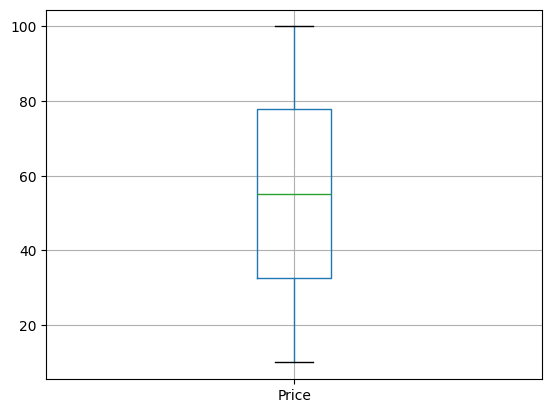

In [25]:
import matplotlib.pyplot as plt

df.boxplot(column="Price")
plt.show()

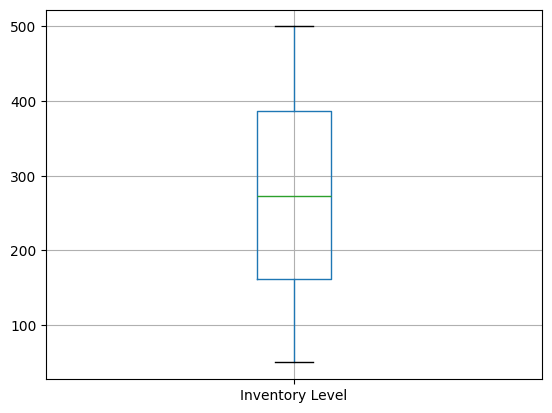

In [26]:
df.boxplot(column="Inventory Level")
plt.show()

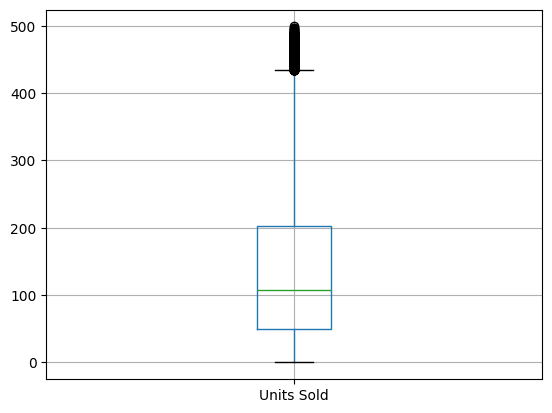

In [27]:
df.boxplot(column="Units Sold")
plt.show()

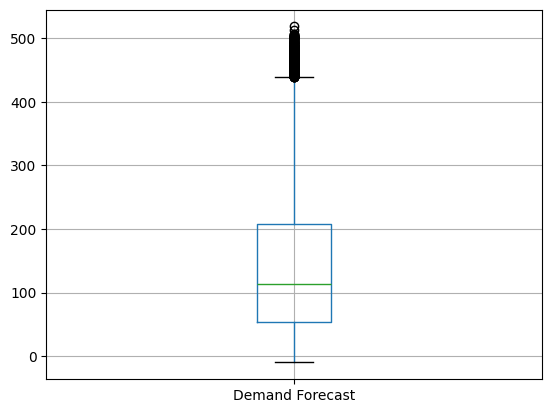

In [28]:
df.boxplot(column="Demand Forecast")
plt.show()

<Axes: >

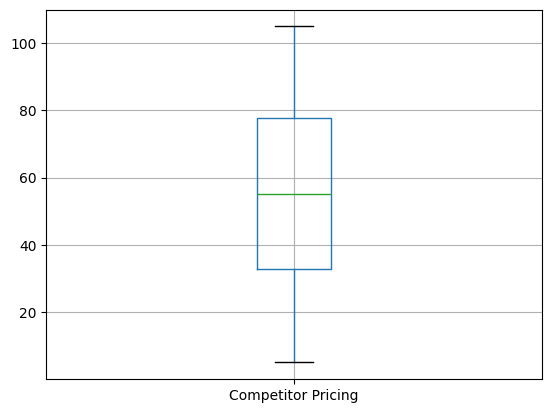

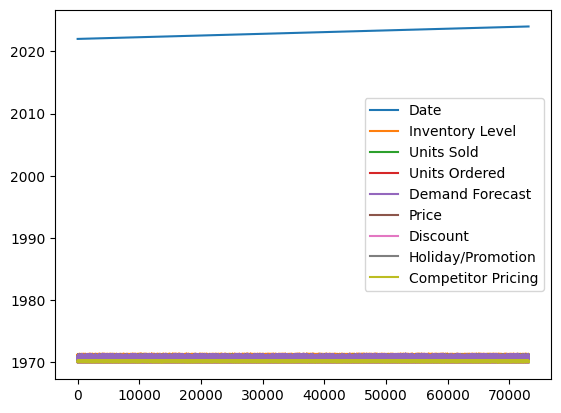

In [29]:
df.boxplot(column="Competitor Pricing")
df.plot()

In [30]:
df["Demand Forecast"] = df["Demand Forecast"].clip(lower=0)

In [31]:
(df["Demand Forecast"] < 0).sum()

np.int64(0)

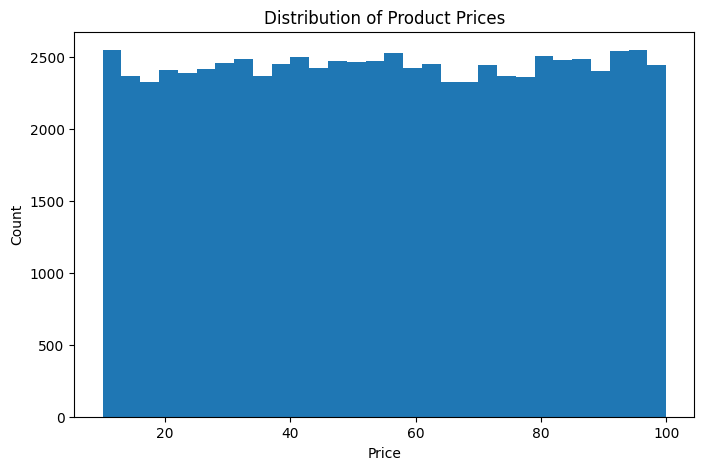

In [32]:
#1. Price Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=30)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

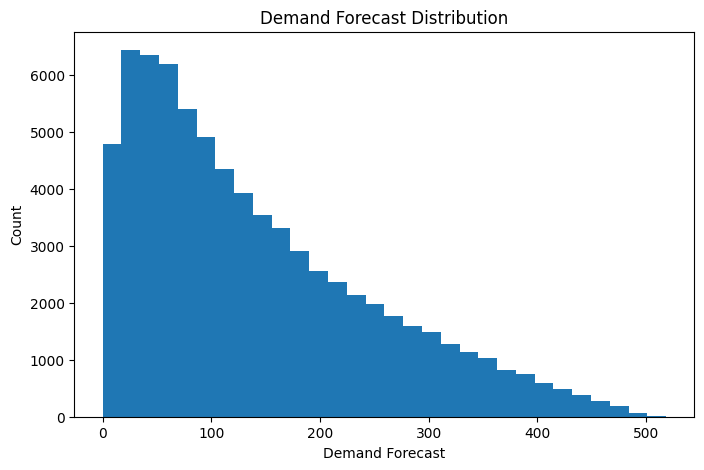

In [33]:
#2. Demand Forecast Distribution
plt.figure(figsize=(8,5))
plt.hist(df["Demand Forecast"], bins=30)
plt.title("Demand Forecast Distribution")
plt.xlabel("Demand Forecast")
plt.ylabel("Count")
plt.show()

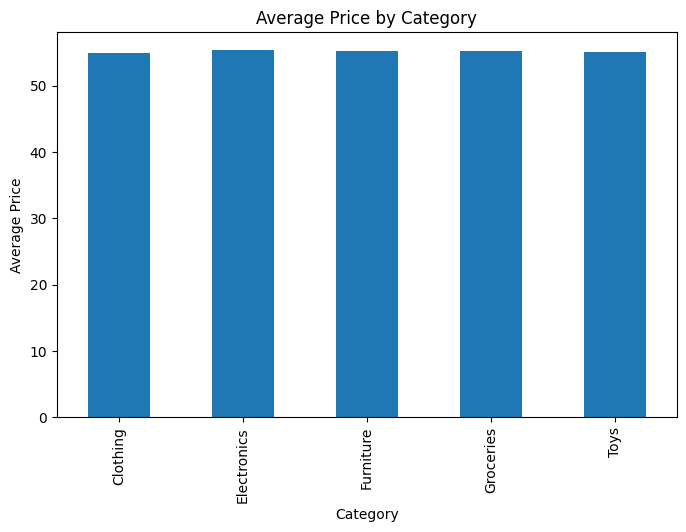

In [34]:
#3. Inventory Distribution
category_price = df.groupby("Category")["Price"].mean()

plt.figure(figsize=(8,5))
category_price.plot(kind="bar")
plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.show()

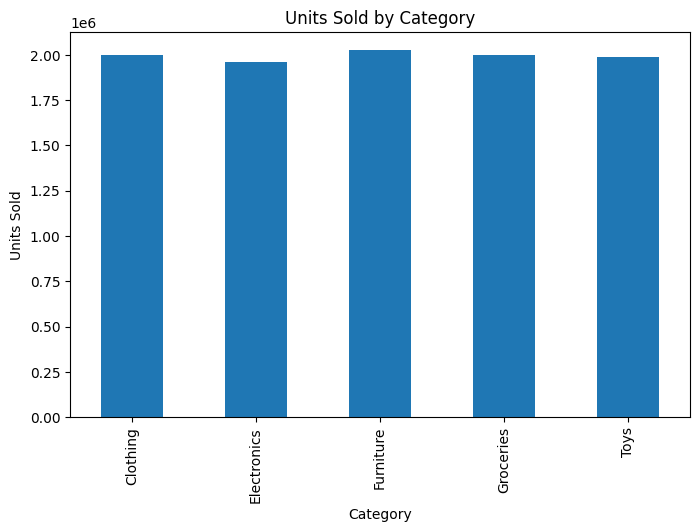

In [35]:
#Units Sold by Category
category_sales = df.groupby("Category")["Units Sold"].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.show()

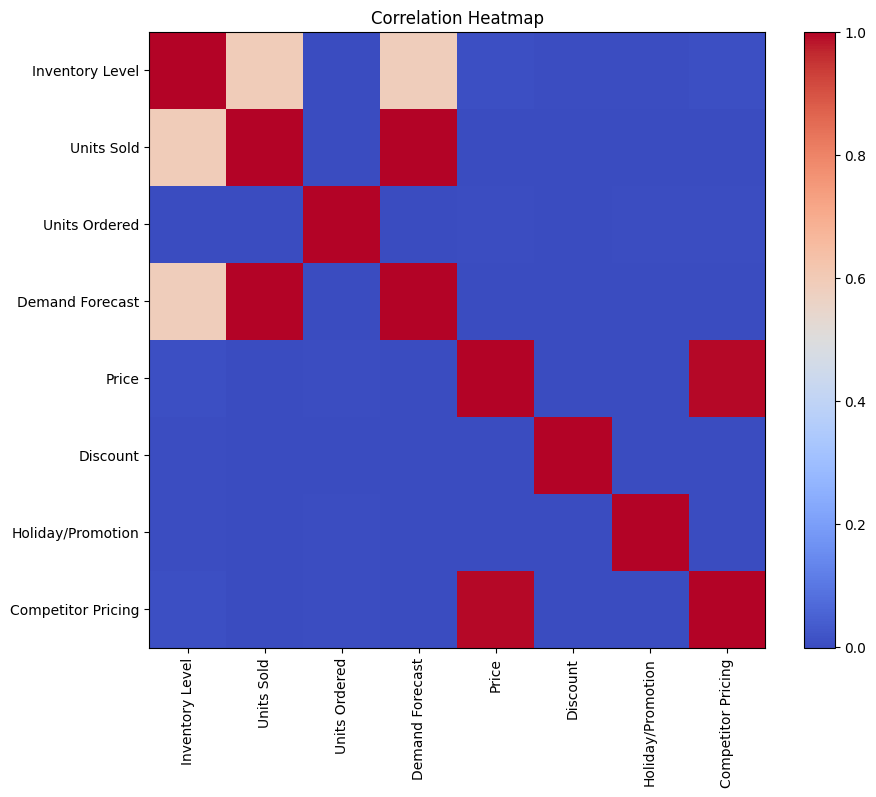

In [36]:
#Part 3: Correlation Analysis
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

In [37]:
# ==================================
# STEP 4 : FEATURE ENGINEERING
# ==================================

In [38]:
#1. Extract Date Features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

In [39]:
#2. Create Inventory-to-Demand Ratio
df["Inventory_Demand_Ratio"] = (
    df["Inventory Level"] /
    (df["Demand Forecast"] + 1)
)

In [40]:
#3. Price Difference from Competitor
df["Price_Difference"] = (
    df["Price"] -
    df["Competitor Pricing"]
)

In [41]:
#4. Discounted Price
df["Discounted_Price"] = (
    df["Price"] *
    (1 - df["Discount"] / 100)
)

In [42]:
#5. Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [43]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,DayOfWeek,Inventory_Demand_Ratio,Price_Difference,Discounted_Price
0,2022-01-01,0,0,3,1,231,127,55,135.47,33.50,...,0,29.69,0,2022,1,1,5,1.692680,3.81,26.800
1,2022-01-01,0,1,4,2,204,150,66,144.04,63.01,...,0,66.16,0,2022,1,1,5,1.406509,-3.15,50.408
2,2022-01-01,0,2,4,3,102,65,51,74.02,27.99,...,1,31.32,2,2022,1,1,5,1.359637,-3.33,25.191
3,2022-01-01,0,3,4,1,469,61,164,62.18,32.72,...,1,34.74,0,2022,1,1,5,7.423235,-2.02,29.448
4,2022-01-01,0,4,1,0,166,14,135,9.26,73.64,...,0,68.95,2,2022,1,1,5,16.179337,4.69,73.640


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    73100 non-null  datetime64[ns]
 1   Store ID                73100 non-null  int64         
 2   Product ID              73100 non-null  int64         
 3   Category                73100 non-null  int64         
 4   Region                  73100 non-null  int64         
 5   Inventory Level         73100 non-null  int64         
 6   Units Sold              73100 non-null  int64         
 7   Units Ordered           73100 non-null  int64         
 8   Demand Forecast         73100 non-null  float64       
 9   Price                   73100 non-null  float64       
 10  Discount                73100 non-null  int64         
 11  Weather Condition       73100 non-null  int64         
 12  Holiday/Promotion       73100 non-null  int64 

In [45]:
# ==================================
# STEP 5 : CREATE RECOMMENDED PRICE
# ==================================

df["Recommended Price"] = df["Price"]

In [46]:
#Rule 1: High Demand
high_demand = df["Demand Forecast"] > df["Demand Forecast"].median()

df.loc[high_demand, "Recommended Price"] *= 1.10

In [47]:
#Rule 2: Low Inventory
low_inventory = df["Inventory Level"] < df["Inventory Level"].median()

df.loc[low_inventory, "Recommended Price"] *= 1.05

In [48]:
#Rule 3: Competitor Price
competitor_higher = df["Competitor Pricing"] > df["Price"]

df.loc[competitor_higher, "Recommended Price"] *= 1.05

In [49]:
#Rule 4: Holiday Promotion
holiday = df["Holiday/Promotion"] == 1

df.loc[holiday, "Recommended Price"] *= 1.03

In [50]:
#Rule 5: Large Discount
high_discount = df["Discount"] >= 15

df.loc[high_discount, "Recommended Price"] *= 0.95

In [51]:
#Rule 6: Overstock
overstock = df["Inventory Level"] > 400

df.loc[overstock, "Recommended Price"] *= 0.95

In [52]:
#Round Prices
df["Recommended Price"] = df["Recommended Price"].round(2)

In [53]:
df[["Price", "Recommended Price"]].head(10)

,Price,Recommended Price
0,33.50,36.76
1,63.01,72.59
2,27.99,31.78
3,32.72,33.62
4,73.64,77.32
5,76.83,95.97
6,34.16,36.94
7,97.99,113.18
8,20.74,23.95
9,59.99,68.12


In [54]:
df["Recommended Price"].describe()

,Recommended Price
count,73100.000000
mean,59.775820
std,28.485174
min,9.370000
25%,35.340000
50%,59.490000
75%,84.060000
max,124.780000


In [55]:
df["Price"].describe()

,Price
count,73100.000000
mean,55.135108
std,26.021945
min,10.000000
25%,32.650000
50%,55.050000
75%,77.860000
max,100.000000


In [56]:
df.to_csv("dynamic_pricing_dataset.csv", index=False)

In [57]:
# setp 6 Model Training


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [59]:
#6.2 Select Features (X)
features = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand Forecast",
    "Discount",
    "Weather Condition",
    "Holiday/Promotion",
    "Competitor Pricing",
    "Seasonality",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Inventory_Demand_Ratio",
    "Price_Difference",
    "Discounted_Price"
]

X = df[features]

In [60]:
y = df["Recommended Price"]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [62]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [63]:
print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE :", mean_squared_error(y_test, lr_pred) ** 0.5)

print("R2 Score :", r2_score(y_test, lr_pred))

Linear Regression
MAE : 2.23943853484884
RMSE : 2.945434738497018
R2 Score : 0.9893783647294363


In [64]:
#.7 Decision Tree
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [65]:
print("Decision Tree")

print("MAE :", mean_absolute_error(y_test, dt_pred))

print("RMSE :", mean_squared_error(y_test, dt_pred) ** 0.5)

print("R2 Score :", r2_score(y_test, dt_pred))

Decision Tree
MAE : 0.8303556771545827
RMSE : 1.2465602796414434
R2 Score : 0.9980975241871634


In [66]:
#6.8 Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [67]:
print("Random Forest")

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", mean_squared_error(y_test, rf_pred) ** 0.5)

print("R2 Score :", r2_score(y_test, rf_pred))

Random Forest
MAE : 0.5910934062927501
RMSE : 0.8151703942645141
R2 Score : 0.9991864404040426


In [68]:
results = {
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        mean_squared_error(y_test, lr_pred) ** 0.5,
        mean_squared_error(y_test, dt_pred) ** 0.5,
        mean_squared_error(y_test, rf_pred) ** 0.5
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.239439,2.945435,0.989378
1,Decision Tree,0.830356,1.246560,0.998098
2,Random Forest,0.591093,0.815170,0.999186


In [69]:
features = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand Forecast",
    "Discount",
    "Weather Condition",
    "Holiday/Promotion",
    "Competitor Pricing",
    "Seasonality",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Inventory_Demand_Ratio"
]

In [70]:
import pickle

with open("dynamic_pricing_model.pkl", "wb") as file:
    pickle.dump(rf, file)

In [71]:
from google.colab import files

files.download("dynamic_pricing_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [73]:
import pickle

# Save the model
with open("dynamic_pricing_model.pkl", "wb") as f:
    pickle.dump(rf, f)

# Save the encoders
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

In [74]:
from google.colab import files

files.download("label_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
import pickle

with open("label_encoders.pkl", "rb") as f:
    label_encoders = pickle.load(f)

print(label_encoders["Store ID"].classes_)
print(label_encoders["Product ID"].classes_)
print(label_encoders["Category"].classes_)

[0 1 2 3 4]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[0 1 2 3 4]


In [76]:
import pandas as pd

df = pd.read_csv("retail_store_inventory.csv")

In [77]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

for col in categorical_columns:
    le = LabelEncoder()
    le.fit(df[col])      # Fit on ORIGINAL text values
    label_encoders[col] = le

In [78]:
print(label_encoders["Store ID"].classes_)

['S001' 'S002' 'S003' 'S004' 'S005']


In [79]:
import pickle

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

In [80]:
from google.colab import files
files.download("label_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [81]:
print(X.columns.tolist())

['Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality', 'Year', 'Month', 'Day', 'DayOfWeek', 'Inventory_Demand_Ratio', 'Price_Difference', 'Discounted_Price']


In [82]:
import pickle

with open("dynamic_pricing_model.pkl", "rb") as f:
    model = pickle.load(f)

print(model.feature_names_in_)

['Store ID' 'Product ID' 'Category' 'Region' 'Inventory Level'
 'Units Sold' 'Units Ordered' 'Demand Forecast' 'Discount'
 'Weather Condition' 'Holiday/Promotion' 'Competitor Pricing'
 'Seasonality' 'Year' 'Month' 'Day' 'DayOfWeek' 'Inventory_Demand_Ratio'
 'Price_Difference' 'Discounted_Price']
